In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 

In [2]:
import spikeinterface.full as si
from pathlib import Path

In [3]:
from configuration import base_path, figure_folder
global_name = 'matching_drift'

# dataset_name = 'Neuronexus-32_50_300.s'
# dataset_name = 'Neuropixels1-128_250_100.s'
# dataset_name = 'Neuropixels1-384_500_600.s'
dataset_name = 'Neuropixels1-384_500_1800.s'

motion_folder = base_path / global_name / dataset_name / 'motion'
study_folder = base_path / global_name / dataset_name / 'study'
# si.set_global_job_kwargs(n_jobs=0.8)
si.set_global_job_kwargs(n_jobs=20, chunk_duration="0.2s")


In [4]:
from spikeinterface.benchmark.benchmark_matching import MatchingStudy
study = MatchingStudy(study_folder)
study

MatchingStudy study 
  datasets: 2 ['static', 'corrected']
  cases: 10 [('wobble', 'static'), ('wobble', 'corrected'), ('circus-omp', 'static'), ('circus-omp', 'corrected'), ('tdc-peeler', 'static'), ('tdc-peeler', 'corrected'), ('kilosort-matching', 'static'), ('kilosort-matching', 'corrected'), ('nearest', 'static'), ('nearest', 'corrected')]
  computed: 10

In [5]:

study.colors_by_case = {
    ('wobble', 'static'): "#E77000",
    ('wobble', 'corrected'): "#E0A268",
    ('circus-omp', 'static'): "#80E200",
    ('circus-omp', 'corrected'): "#C0EE83",
    ('tdc-peeler', 'static'): "#BBBE00",
    ('tdc-peeler', 'corrected'): "#EAEBBF",
    ('kilosort-matching', 'static'): "#A200FF",
    ('kilosort-matching', 'corrected'): "#CE88F7",
}

# change labels to avoid re run
study.cases[('wobble', 'static')]['label'] = 'Wobble | static'
study.cases[('wobble', 'corrected')]['label'] = 'Wobble | motion-corrected'
study.cases[('circus-omp', 'static')]['label'] = 'Circus-OMP | static'
study.cases[('circus-omp', 'corrected')]['label'] = 'Circus-OMP | motion-corrected'
study.cases[('kilosort-matching', 'static')]['label'] = 'KS-matching | static'
study.cases[('kilosort-matching', 'corrected')]['label'] = 'KS-matching | motion-corrected'
study.cases[('tdc-peeler', 'static')]['label'] = 'TDC-peeler | static'
study.cases[('tdc-peeler', 'corrected')]['label'] = 'TDC-peeler | motion-corrected'


In [6]:
all_cases = list(study.cases.keys())
static_cases = all_cases[::2]
drifting_cases = all_cases[1::2]

# debug
static_cases = static_cases[:-1]
drifting_cases = drifting_cases[:-1]
all_cases = static_cases + drifting_cases

print(static_cases)
print(drifting_cases)


[('wobble', 'static'), ('circus-omp', 'static'), ('tdc-peeler', 'static'), ('kilosort-matching', 'static')]
[('wobble', 'corrected'), ('circus-omp', 'corrected'), ('tdc-peeler', 'corrected'), ('kilosort-matching', 'corrected')]


In [ ]:
# fig = study.plot_collisions(case_keys=static_cases, show_legend=False,  metric="l1", mode="lines", figsize=(10, 5))

/home/samuel.garcia/Documents/SpikeInterface/spikeinterface/src/spikeinterface/widgets/collision.py:168: RuntimeWarning: Mean of empty slice
  mean_recall_scores = np.nanmean(recall_scores[amin:amax], axis=0)
/home/samuel.garcia/Documents/SpikeInterface/spikeinterface/src/spikeinterface/widgets/collision.py:168: RuntimeWarning: Mean of empty slice
  mean_recall_scores = np.nanmean(recall_scores[amin:amax], axis=0)
/home/samuel.garcia/Documents/SpikeInterface/spikeinterface/src/spikeinterface/widgets/collision.py:168: RuntimeWarning: Mean of empty slice
  mean_recall_scores = np.nanmean(recall_scores[amin:amax], axis=0)
/home/samuel.garcia/Documents/SpikeInterface/spikeinterface/src/spikeinterface/widgets/collision.py:168: RuntimeWarning: Mean of empty slice
  mean_recall_scores = np.nanmean(recall_scores[amin:amax], axis=0)
/tmp/ipykernel_316948/293532773.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight

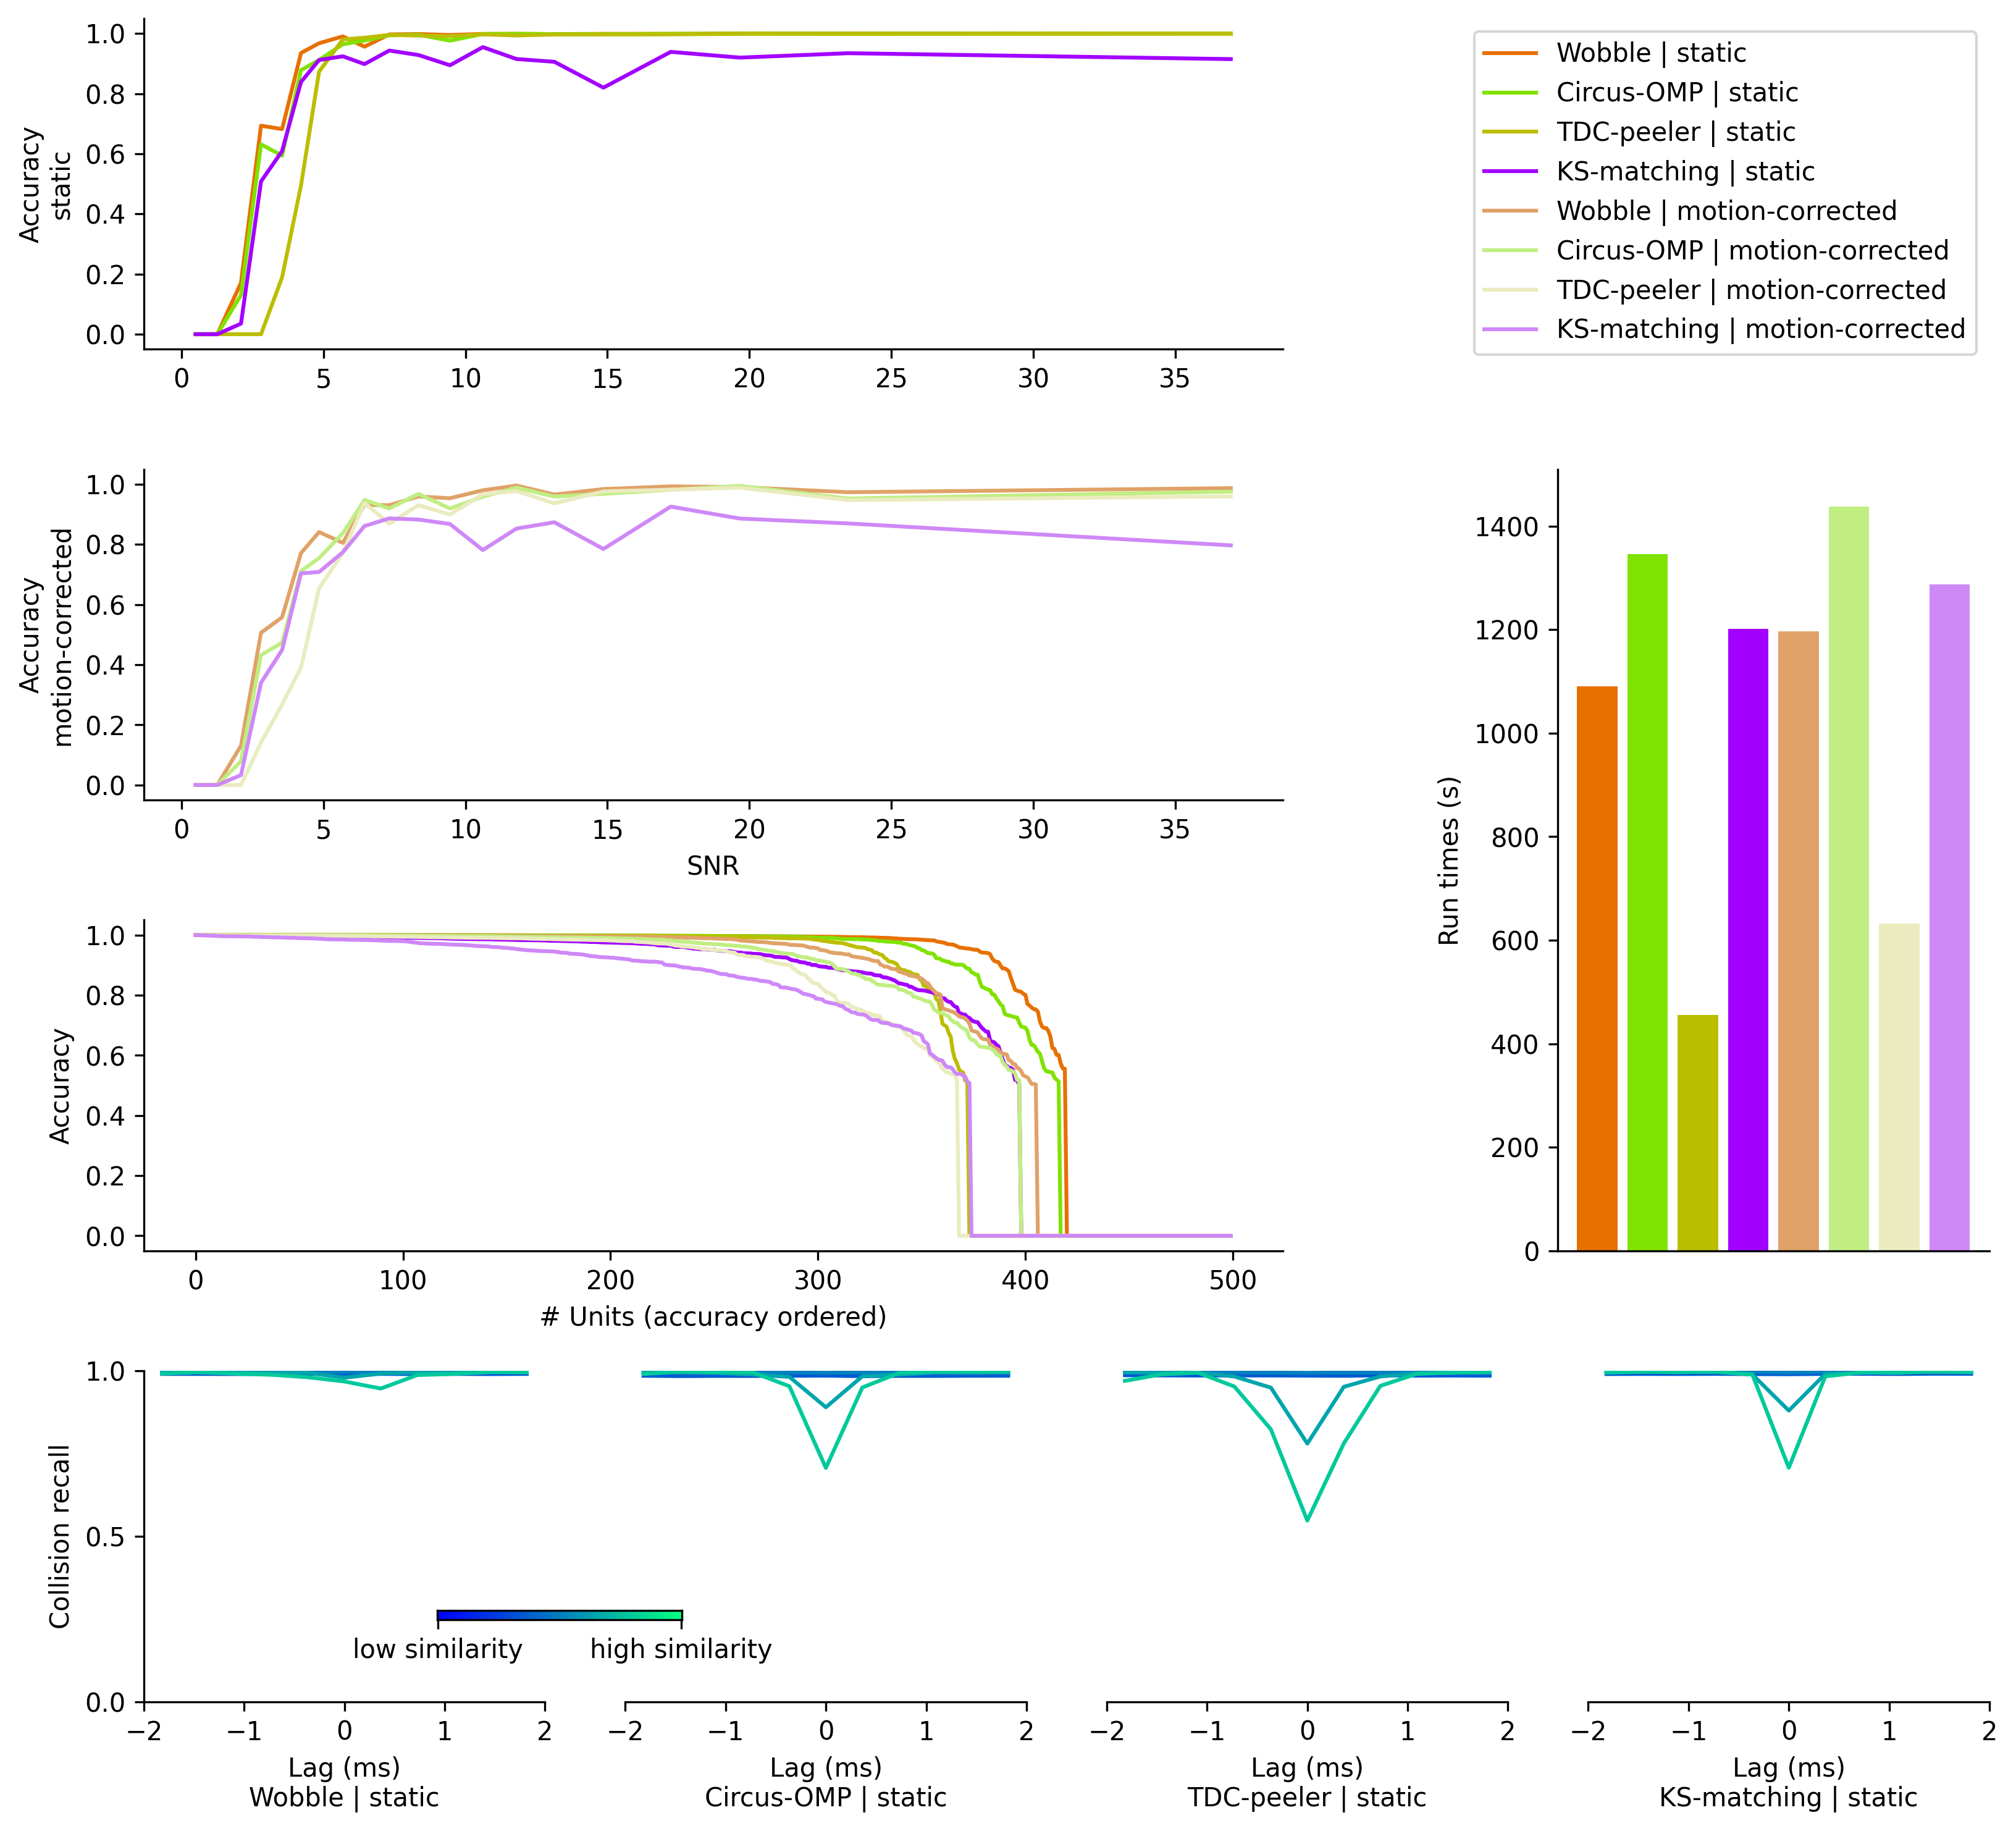

In [8]:
%matplotlib inline
myparams = {
    'axes.titlesize' : 11,
    'axes.labelsize' : 10,
    'legend.fontsize': 10,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
}


import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
from spikeinterface.benchmark.benchmark_plot_tools import despine, clean_axis, plot_study_legend
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


with mpl.rc_context(myparams):

    fig = plt.figure(figsize=(11, 10), dpi=300)

    gs = GridSpec(4, 1, figure=fig)
    gs0 = GridSpecFromSubplotSpec(3, 8, subplot_spec=gs[:3, 0])
    ax1 = fig.add_subplot(gs0[0,:5])
    ax2 = fig.add_subplot(gs0[1,:5])
    ax3 = fig.add_subplot(gs0[0, 6:8])
    ax4 = fig.add_subplot(gs0[1:3, 6:8])
    ax5 = fig.add_subplot(gs0[2, :5])
    gs1 = GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[3, 0])
    axs6 = [fig.add_subplot(gs1[0, i]) for i in range(4)]
    # axs7 = [fig.add_subplot(gs1[1, i]) for i in range(4)]
    ax7 = fig.add_axes((0.22, 0.12, 0.12, 0.005))




    plot_study_legend(study, case_keys=all_cases, ax=ax3)


    _ = study.plot_performances_vs_snr(case_keys=static_cases, performance_names=['accuracy'],
                                       show_scatter=False,
                                        with_sigmoid_fit=False,
                                        show_average_by_bin=True, 
                                        scatter_size=1,
                                        scatter_alpha=0.25,
                                        metric_dataset_reference='static',
                                       axs=[ax1], show_legend=False)
    ax1.set_ylabel('Accuracy\nstatic')

    _ = study.plot_performances_vs_snr(case_keys=drifting_cases, performance_names=['accuracy'],
                                       show_scatter=False,
                                        with_sigmoid_fit=False,
                                        show_average_by_bin=True, 
                                        scatter_size=1,
                                        scatter_alpha=0.25,
                                        metric_dataset_reference='static',                                        

                                       axs=[ax2], show_legend=False)
    ax2.set_xlabel('SNR')
    ax2.set_ylabel('Accuracy\nmotion-corrected')



    _ = study.plot_run_times(case_keys=all_cases,ax=ax4)
    ax4.set_xticks([])
    ax4.set_xticklabels([])
    despine(ax4)
    
    _ = study.plot_performances_ordered(case_keys=all_cases, performance_names=['accuracy'],
                                    axs=[ax5], show_legend=False)
    ax5.set_title('')
    ax5.set_xlabel('# Units (accuracy ordered)')
    ax5.set_ylabel('Accuracy')


    _ = study.plot_collisions(case_keys=static_cases, show_legend=False,
                              mode="lines",
                              axs=axs6)


    names = [study.cases[k]['label'] for k in list(study.cases.keys())[::2]]
    for i, ax in enumerate(axs6):
        ax.set_title('')
        sorter_name = static_cases[i][0]
        if i == 0:
            ax.set_ylabel('Collision recall')
            ax.set_yticks([0., 0.5, 1.])
        else:
            ax.set_ylabel('')
            ax.set_yticks([])
            ax.spines["left"].set_visible(False)

        name = names[i]
        ax.set_xlabel(f'Lag (ms)\n{name}')
        despine(ax)



    ax7.imshow(np.linspace(0, 1, 256)[None, :], aspect='auto', cmap=mpl.colormaps['winter'])
    ax7.set_yticks([])
    ax7.set_xticks([0, 255])
    ax7.set_xticklabels(['low similarity', 'high similarity'])




    fig.tight_layout(pad=1.15)


    fig.savefig(figure_folder / 'figure_matching.png')
    fig.savefig(figure_folder / 'figure_matching.pdf')

